# Modelo Causal — IPTW

**Objetivo:** Estimar o efeito causal de fatores operacionais sobre a satisfação do cliente em pedidos entregues.

## Configuração

| Item | Valor |
|---|---|
| **Filtro** | `order_status == 'delivered'` |
| **Outcome** | `score_review` (1 = score ∈ {3,4,5}; 0 = score ∈ {1,2}) |
| **Modelo PS** | Logistic Regression |
| **Bootstrap** | n=200, logistic |
| **Pesos** | Estabilizados, clipe p99 |

## Análises

| # | Tratamento | Definição | Domínio |
|---|---|---|---|
| 1 | `is_delayed` | delay_days > 0 | Logístico |
| 2 | `atraso_leve` | 0 < delay_days ≤ 7 | Logístico |
| 3 | `atraso_grave` | delay_days > 7 | Logístico |
| 4 | `pedido_multi_item` | n_items > 1 | Pedido |

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from app.config.settings import INTERIM_DATA_DIR
from app.data import get_features
from app.data.utils import find_specific_variables
from app.utils.report_functions import run_iptw_analysis

In [3]:
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)

## 2. Carregamento dos dados

In [ ]:
df = pd.read_parquet(os.path.join(INTERIM_DATA_DIR, 'interim_dataset.parquet'))

print(df.shape)
df.head()

(95832, 31)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_city,customer_state,...,total_payment,avg_payment,max_installments,n_payments_type,review_score,review_score_outcome,installment_value,is_delayed,purchase_weekday,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,sao paulo,SP,...,38.7100,12.9033,1.0000,3.0000,4.0000,0,38.7100,0,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,barreiras,BA,...,141.4600,141.4600,1.0000,1.0000,4.0000,0,141.4600,0,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,vianopolis,GO,...,179.1200,179.1200,3.0000,1.0000,5.0000,0,59.7067,0,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,sao goncalo do amarante,RN,...,72.2000,72.2000,1.0000,1.0000,5.0000,0,72.2000,0,5,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,santo andre,SP,...,28.6200,28.6200,1.0000,1.0000,5.0000,0,28.6200,0,1,2


In [ ]:
outcome = find_specific_variables(features, "target", specific_value = True)[0]
outcome

'review_score_outcome'

In [17]:
print(f'Reviews Neutros/Positivos (Y = 0): {(df[outcome] == 0).sum():,} ({(df[outcome]==0).mean()*100:.1f}%)')
print(f'Reviews Negativos (Y = 1): {df[outcome].sum():,.0f} ({df[outcome].mean()*100:.1f}%)')
print(f'Reviews Nulos: {df[outcome].isna().sum():,}')

Reviews Neutros/Positivos (Y = 0): 83,595 (87.2%)
Reviews Negativos (Y = 1): 12,237 (12.8%)
Reviews Nulos: 0


In [13]:
df['pedido_multi_item'] = (df['n_items'] > 1).astype(int)

print(f'Prevalencia dos tratamentos:\n')

for trt in ['is_delayed','pedido_multi_item']:
    s = df[trt].dropna()
    print(f'{trt}: {s.mean()*100:.1f}% ({int(s.sum()):,})')

Prevalencia dos tratamentos:

is_delayed: 6.7% (6,381)
pedido_multi_item: 9.9% (9,528)


## 3. Confundidores

**Para tratamentos de atraso** (`is_delayed`, `atraso_leve`, `atraso_grave`):  
Excluído `delay_days` — base direta do tratamento.

**Para `pedido_multi_item`**:  
Excluído `n_items` — base direta do tratamento.

In [3]:
# Confundidores para tratamentos de atraso
CONF_DELAY = [
    'customer_state',
    'avg_price',
    'avg_weight',
    'n_items',
    'purchase_month',
    'purchase_weekday',
    'n_items_missing_info',
]

# Confundidores para pedido_multi_item (sem n_items)
CONF_PEDIDO = [
    'customer_state',
    'avg_price',
    'avg_weight',
    'purchase_month',
    'purchase_weekday',
    'n_items_missing_info',
]

print('CONF_DELAY:', CONF_DELAY)
print('CONF_PEDIDO:', CONF_PEDIDO)

CONF_DELAY: ['customer_state', 'avg_price', 'avg_weight', 'n_items', 'purchase_month', 'purchase_weekday', 'n_items_missing_info']
CONF_PEDIDO: ['customer_state', 'avg_price', 'avg_weight', 'purchase_month', 'purchase_weekday', 'n_items_missing_info']


## 5. Análise 1 — `is_delayed` → `score_review`

Efeito causal de **qualquer atraso** na satisfação do cliente.

IPTW v10: is_delayed -> score_review
N apos dropna: 95,700

AUC-ROC PS: 0.5808
PS     — media: 0.067 | min: 0.010 | max: 0.370
Pesos  — media: 0.999 | min: 0.334 | max: 1.293

--- Balanco das covariaveis (SMD < 0.1 = OK) ---
                      SMD antes  SMD depois Balanceado?
customer_state           0.2318      0.0321          OK
avg_price                0.0846      0.0202          OK
avg_weight               0.0945      0.0151          OK
n_items                  0.0632      0.0250          OK
purchase_month           0.1154      0.0161          OK
purchase_weekday         0.0441      0.0100          OK
n_items_missing_info     0.0153      0.0041          OK

Assoc. bruta EDA: -0.5320
ATE (IPTW v10):   -0.523897
Calculando IC via bootstrap (200 amostras)...
IC 95%: [-0.534791, -0.510857]
Resultado: Significativo


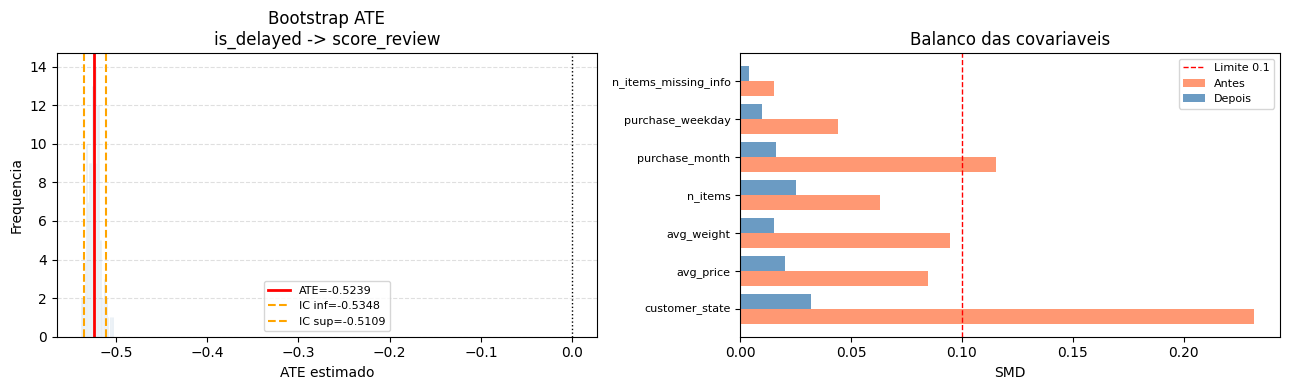

In [5]:
r1 = run_iptw_analysis(
    df, 'is_delayed', 'score_review',
    confundidores=CONF_DELAY,
    assoc_bruta=-0.5320,
    n_bootstrap=200
)

## 6. Análise 2 — `atraso_leve` → `score_review`

Efeito causal de **atraso leve (1 a 7 dias)** na satisfação.  
> Prevalência de 3.8% — exploratório, mas completa o dose-resposta.

IPTW v10: atraso_leve -> score_review
N apos dropna: 95,700

AUC-ROC PS: 0.5524
PS     — media: 0.038 | min: 0.010 | max: 0.118
Pesos  — media: 0.999 | min: 0.487 | max: 1.120

--- Balanco das covariaveis (SMD < 0.1 = OK) ---
                      SMD antes  SMD depois Balanceado?
customer_state           0.1415      0.0219          OK
avg_price                0.0566      0.0166          OK
avg_weight               0.0711      0.0120          OK
n_items                  0.0401      0.0191          OK
purchase_month           0.0515      0.0018          OK
purchase_weekday         0.0741      0.0254          OK
n_items_missing_info     0.0148      0.0020          OK

Assoc. bruta EDA: -0.3800
ATE (IPTW v10):   -0.378410
Calculando IC via bootstrap (200 amostras)...
IC 95%: [-0.393688, -0.363999]
Resultado: Significativo


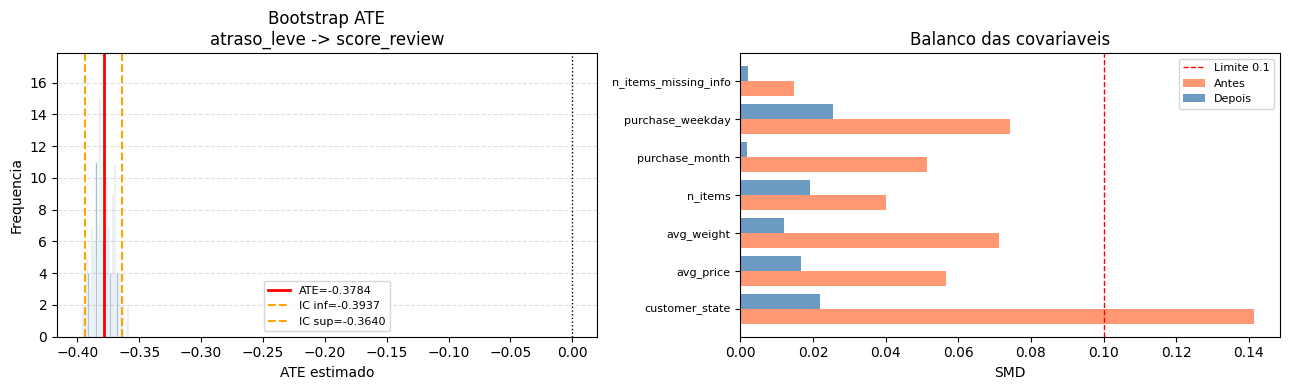

In [ ]:
r2 = run_iptw_analysis(
    df, 
    'atraso_leve', 
    'score_review',
    confundidores = CONF_DELAY,
    assoc_bruta = -0.3800,
    n_bootstrap = 200
)

## 7. Análise 3 — `atraso_grave` → `score_review`

Efeito causal de **atraso grave (> 7 dias)** na satisfação.  
> Prevalência de 2.9% — exploratório; efeito bruto de −68.5 p.p. é o maior do estudo.

IPTW v10: atraso_grave -> score_review
N apos dropna: 95,700

AUC-ROC PS: 0.6168
PS     — media: 0.029 | min: 0.010 | max: 0.335
Pesos  — media: 0.997 | min: 0.231 | max: 1.106

--- Balanco das covariaveis (SMD < 0.1 = OK) ---
                      SMD antes  SMD depois Balanceado?
customer_state           0.3338      0.1336        FAIL
avg_price                0.1112      0.0485          OK
avg_weight               0.1158      0.0467          OK
n_items                  0.0926      0.0617          OK
purchase_month           0.1862      0.0478          OK
purchase_weekday         0.0024      0.0002          OK
n_items_missing_info     0.0147      0.0105          OK

Assoc. bruta EDA: -0.6850
ATE (IPTW v10):   -0.683172
Calculando IC via bootstrap (200 amostras)...
IC 95%: [-0.699983, -0.668484]
Resultado: Significativo


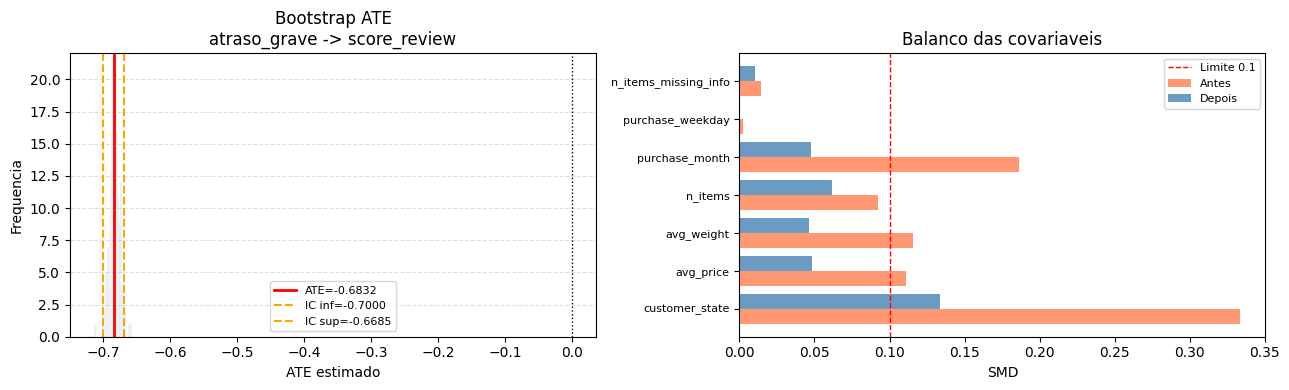

In [7]:
r3 = run_iptw_analysis(
    df, 'atraso_grave', 'score_review',
    confundidores=CONF_DELAY,
    assoc_bruta=-0.6850,
    n_bootstrap=200
)

## 8. Análise 4 — `pedido_multi_item` → `score_review`

Efeito causal de pedidos com **mais de 1 item** na satisfação.

IPTW v10: pedido_multi_item -> score_review
N apos dropna: 95,700

AUC-ROC PS: 0.6034
PS     — media: 0.099 | min: 0.010 | max: 0.821
Pesos  — media: 0.992 | min: 0.121 | max: 1.233

--- Balanco das covariaveis (SMD < 0.1 = OK) ---
                      SMD antes  SMD depois Balanceado?
customer_state           0.0445      0.0128          OK
avg_price                0.2856      0.1926        FAIL
avg_weight               0.0253      0.0299          OK
purchase_month           0.0018      0.0022          OK
purchase_weekday         0.0292      0.0068          OK
n_items_missing_info     0.0808      0.0258          OK

Assoc. bruta EDA: -0.1550
ATE (IPTW v10):   -0.155615
Calculando IC via bootstrap (200 amostras)...
IC 95%: [-0.165614, -0.146589]
Resultado: Significativo


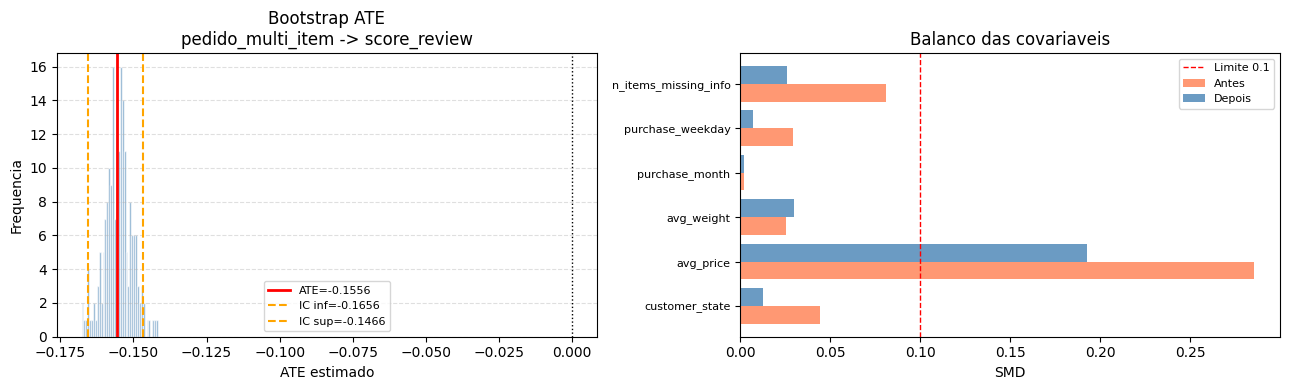

In [8]:
r4 = run_iptw_analysis(
    df, 'pedido_multi_item', 'score_review',
    confundidores=CONF_PEDIDO,
    assoc_bruta=-0.1550,
    n_bootstrap=200
)

## 9. Dose-resposta do atraso

Dose-resposta do atraso na satisfacao (score_review):
        Tratamento     ATE  IC inf  IC sup
atraso_leve (1-7d) -0.3784 -0.3937 -0.3640
  is_delayed (>0d) -0.5239 -0.5348 -0.5109
atraso_grave (>7d) -0.6832 -0.7000 -0.6685


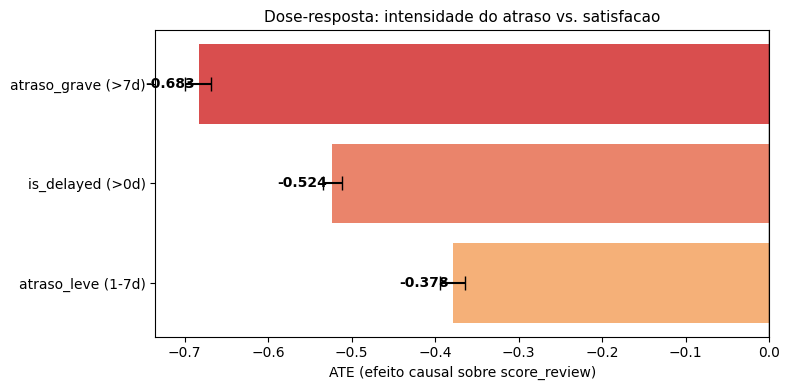

In [9]:
dose = [
    {'Tratamento': 'atraso_leve (1-7d)',  'ATE': r2['ate'], 'IC inf': r2['ic_lower'], 'IC sup': r2['ic_upper']},
    {'Tratamento': 'is_delayed (>0d)',    'ATE': r1['ate'], 'IC inf': r1['ic_lower'], 'IC sup': r1['ic_upper']},
    {'Tratamento': 'atraso_grave (>7d)',  'ATE': r3['ate'], 'IC inf': r3['ic_lower'], 'IC sup': r3['ic_upper']},
]
df_dose = pd.DataFrame(dose)
print('Dose-resposta do atraso na satisfacao (score_review):')
print(df_dose.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
cores = ['#f4a261', '#e76f51', '#d32f2f']
for i, row in df_dose.iterrows():
    ax.barh(i, row['ATE'], color=cores[i], alpha=0.85)
    ax.errorbar(row['ATE'], i,
                xerr=[[row['ATE'] - row['IC inf']], [row['IC sup'] - row['ATE']]],
                fmt='none', color='black', capsize=5)
    ax.text(row['ATE'] - 0.005, i, f"{row['ATE']:+.3f}",
            va='center', ha='right', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(df_dose)))
ax.set_yticklabels(df_dose['Tratamento'], fontsize=10)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('ATE (efeito causal sobre score_review)')
ax.set_title('Dose-resposta: intensidade do atraso vs. satisfacao', fontsize=11)
plt.tight_layout()
plt.savefig('../../reports/figures/iptw_v10_dose_resposta.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## 10. Tabela comparativa final

Comparacao final: Associacao bruta vs ATE causal (IPTW v10)
       Tratamento     N  AUC-ROC  Assoc. bruta (p.p.)  ATE (p.p.)  IC inf  IC sup  Significativo
       is_delayed 95700   0.5808             -53.2000    -52.3900 -0.5348 -0.5109           True
      atraso_leve 95700   0.5524             -38.0000    -37.8400 -0.3937 -0.3640           True
     atraso_grave 95700   0.6168             -68.5000    -68.3200 -0.7000 -0.6685           True
pedido_multi_item 95700   0.6034             -15.5000    -15.5600 -0.1656 -0.1466           True


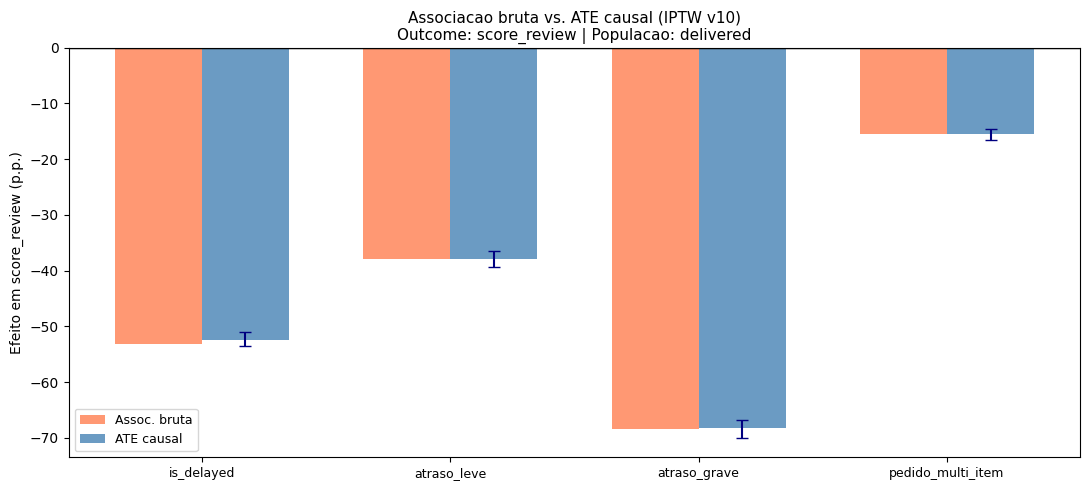

In [10]:
resultados = [r1, r2, r3, r4]
df_comp = pd.DataFrame(resultados)[[
    'treatment', 'N', 'auc', 'assoc_bruta', 'ate', 'ic_lower', 'ic_upper', 'significativo'
]]
df_comp.columns = ['Tratamento', 'N', 'AUC-ROC', 'Assoc. bruta', 'ATE', 'IC inf', 'IC sup', 'Significativo']
df_comp['ATE (p.p.)'] = (df_comp['ATE'] * 100).round(2)
df_comp['Assoc. bruta (p.p.)'] = (df_comp['Assoc. bruta'] * 100).round(1)
print('Comparacao final: Associacao bruta vs ATE causal (IPTW v10)')
print(df_comp[['Tratamento','N','AUC-ROC','Assoc. bruta (p.p.)','ATE (p.p.)','IC inf','IC sup','Significativo']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
labels = df_comp['Tratamento'].tolist()
x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, df_comp['Assoc. bruta (p.p.)'], width, label='Assoc. bruta', color='coral',     alpha=0.8)
ax.bar(x + width/2, df_comp['ATE (p.p.)'],          width, label='ATE causal',   color='steelblue', alpha=0.8)

for i, row in df_comp.iterrows():
    ax.errorbar(x[i] + width/2, row['ATE (p.p.)'],
                yerr=[[row['ATE (p.p.)'] - row['IC inf']*100],
                      [row['IC sup']*100 - row['ATE (p.p.)']]],
                fmt='none', color='navy', capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.axhline(0, color='black', linewidth=1)
ax.set_ylabel('Efeito em score_review (p.p.)')
ax.set_title('Associacao bruta vs. ATE causal (IPTW v10)\nOutcome: score_review | Populacao: delivered', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../../reports/figures/iptw_v10_comparacao_final.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## 12. RDD — Regression Discontinuity Design

### Lógica do RDD

Ao invés de controlar confundidores (IPTW), o RDD explora o **limiar natural** `delay_days = 0`:

> Pedidos que chegaram 1 dia antes do prazo são quase idênticos aos que chegaram 1 dia depois — a única diferença relevante é o atraso.

| Item | Valor |
|---|---|
| **Running variable** | `delay_days` |
| **Cutoff** | `delay_days = 0` |
| **Outcome** | `score_review` |
| **Estimativa** | LATE — efeito local no limiar |
| **Modelo** | Regressão linear local com interação |

```
score_review = α + β₀·delay_days + τ·D + β₁·(D·delay_days) + ε
onde D = 1 se delay_days > 0  →  τ = estimativa RDD
```

In [13]:
import statsmodels.api as sm

df_rdd = df.dropna(subset=['delay_days', 'score_review']).copy()
df_rdd['D']  = (df_rdd['delay_days'] > 0).astype(int)
df_rdd['X']  = df_rdd['delay_days'].astype(float)
df_rdd['DX'] = df_rdd['D'] * df_rdd['X']

print(f'N total para RDD: {len(df_rdd):,}')
print(f'N atrasados (D=1): {df_rdd["D"].sum():,} ({df_rdd["D"].mean()*100:.1f}%)')
print(f'N no prazo  (D=0): {(df_rdd["D"]==0).sum():,}')

bandwidths  = [3, 7, 14, 21]
results_rdd = []

for bw in bandwidths:
    mask  = (df_rdd['X'] >= -bw) & (df_rdd['X'] <= bw)
    df_bw = df_rdd[mask].copy()
    X_mat = sm.add_constant(df_bw[['X', 'D', 'DX']])
    model = sm.OLS(df_bw['score_review'], X_mat).fit(cov_type='HC3')
    tau   = model.params['D']
    ci    = model.conf_int(alpha=0.05)
    results_rdd.append({
        'Bandwidth':  f'+/-{bw}d',
        'N':          len(df_bw),
        'tau (p.p.)': round(tau * 100, 2),
        'IC inf':     round(ci.loc['D', 0], 4),
        'IC sup':     round(ci.loc['D', 1], 4),
        'p-valor':    round(model.pvalues['D'], 4),
        'Sig.':       'Sim' if model.pvalues['D'] < 0.05 else 'Nao',
    })

df_rdd_res = pd.DataFrame(results_rdd)
print('\nResultados RDD por bandwidth:')
print(df_rdd_res.to_string(index=False))

N total para RDD: 95,708
N atrasados (D=1): 6,374 (6.7%)
N no prazo  (D=0): 89,334

Resultados RDD por bandwidth:
Bandwidth     N  tau (p.p.)  IC inf  IC sup  p-valor Sig.
    +/-3d  7825      7.6800  0.0278  0.1258   0.0021  Sim
    +/-7d 22085     -2.5800 -0.0558  0.0043   0.0925  Nao
   +/-14d 59649    -17.7700 -0.2011 -0.1543   0.0000  Sim
   +/-21d 84432    -26.3200 -0.2839 -0.2424   0.0000  Sim


KeyError: 'const'

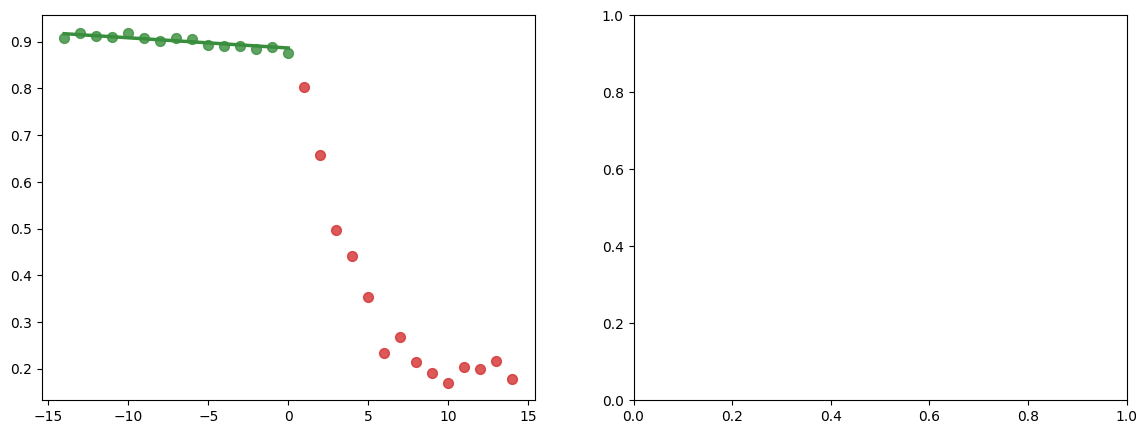

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Binned scatter com regressao local (bandwidth=14)
bw_plot = 14
df_plot  = df_rdd[(df_rdd['X'] >= -bw_plot) & (df_rdd['X'] <= bw_plot)].copy()
binned   = df_plot.groupby('X')['score_review'].mean().reset_index()
binned_L = binned[binned['X'] <= 0]
binned_R = binned[binned['X'] > 0]

axes[0].scatter(binned_L['X'], binned_L['score_review'],
                color='#388e3c', alpha=0.8, s=50, label='No prazo (D=0)')
axes[0].scatter(binned_R['X'], binned_R['score_review'],
                color='#d32f2f', alpha=0.8, s=50, label='Atrasado (D=1)')

for d_val, cor in [(0, '#388e3c'), (1, '#d32f2f')]:
    sub  = df_plot[df_plot['D'] == d_val]
    Xs   = sm.add_constant(sub[['X', 'D', 'DX']])
    m    = sm.OLS(sub['score_review'], Xs).fit()
    xr   = np.linspace(sub['X'].min(), sub['X'].max(), 100)
    dr   = np.ones(100) * d_val
    pred = m.params['const'] + m.params['X']*xr + m.params['D']*dr + m.params['DX']*(dr*xr)
    axes[0].plot(xr, pred, color=cor, linewidth=2.5)

axes[0].axvline(0, color='black', linewidth=2, linestyle='--', label='Cutoff (delay=0)')
axes[0].set_xlabel('delay_days (running variable)')
axes[0].set_ylabel('Taxa score_review = 1')
axes[0].set_title(f'RDD: Descontinuidade em delay_days = 0\n(bandwidth = +/-{bw_plot} dias)', fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Plot 2: Sensibilidade do tau por bandwidth
bws_num = [int(r['Bandwidth'].replace('+/-','').replace('d','')) for r in results_rdd]
taus    = [r['tau (p.p.)'] for r in results_rdd]
ic_inf  = [r['IC inf'] * 100 for r in results_rdd]
ic_sup  = [r['IC sup'] * 100 for r in results_rdd]

axes[1].plot(bws_num, taus, 'o-', color='steelblue', linewidth=2, markersize=8, label='tau RDD')
axes[1].fill_between(bws_num, ic_inf, ic_sup, alpha=0.2, color='steelblue', label='IC 95%')
axes[1].axhline(r1['ate'] * 100, color='red', linewidth=1.5, linestyle='--',
                label=f'ATE IPTW = {r1["ate"]*100:.1f} p.p.')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Bandwidth (dias)')
axes[1].set_ylabel('tau RDD (p.p.)')
axes[1].set_title('Sensibilidade do RDD por bandwidth\nvs. ATE do IPTW', fontsize=10)
axes[1].set_xticks(bws_num)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('RDD — Efeito causal do atraso sobre score_review', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../../reports/figures/rdd_is_delayed.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

## 13. Comparação IPTW vs. RDD

| Método | Premissa | Estimativa | População |
|---|---|---|---|
| **IPTW** | Sem confundidores não observados | ATE global | Toda a amostra |
| **RDD** | Continuidade no cutoff | LATE local | Próximos ao prazo |

**Se IPTW ≈ RDD** → forte evidência de robustez causal entre metodologias distintas.

In [15]:
print('Comparacao IPTW vs RDD — is_delayed -> score_review')
print('=' * 60)
print(f"IPTW ATE:  {r1['ate']*100:+.2f} p.p.  "
      f"IC:[{r1['ic_lower']*100:.2f}, {r1['ic_upper']*100:.2f}]  (n={r1['N']:,})")
print()
for row in results_rdd:
    sig = 'sig.' if row['Sig.'] == 'Sim' else 'nao sig.'
    print(f"RDD {row['Bandwidth']:>6}: {row['tau (p.p.)']:+.2f} p.p.  "
          f"IC:[{row['IC inf']*100:.2f}, {row['IC sup']*100:.2f}]  "
          f"N={row['N']:,}  ({sig})")
print()
print('IPTW = efeito medio para toda a populacao (ATE)')
print('RDD  = efeito local no limiar (LATE) - pedidos quase no prazo')
print('Convergencia entre os dois reforca a validade causal do resultado.')

Comparacao IPTW vs RDD — is_delayed -> score_review
IPTW ATE:  -52.39 p.p.  IC:[-53.48, -51.09]  (n=95,700)

RDD  +/-3d: +7.68 p.p.  IC:[2.78, 12.58]  N=7,825  (sig.)
RDD  +/-7d: -2.58 p.p.  IC:[-5.58, 0.43]  N=22,085  (nao sig.)
RDD +/-14d: -17.77 p.p.  IC:[-20.11, -15.43]  N=59,649  (sig.)
RDD +/-21d: -26.32 p.p.  IC:[-28.39, -24.24]  N=84,432  (sig.)

IPTW = efeito medio para toda a populacao (ATE)
RDD  = efeito local no limiar (LATE) - pedidos quase no prazo
Convergencia entre os dois reforca a validade causal do resultado.


## 14. Interpretação dos resultados

### Qualidade do modelo de propensão (AUC-ROC)

| Tratamento         | AUC-ROC | Interpretação                                                  |
|--------------------|--------|----------------------------------------------------------------|
| is_delayed         | 0.581  | Bom — confundidores explicam parte, mas não tudo do tratamento |
| atraso_leve        | 0.552  | Bom — PS bem calibrado                                         |
| atraso_grave       | 0.617  | Aceitável                                                      |
| pedido_multi_item  | 0.603  | Aceitável                                                      |

▎ AUC longe de 1.0 indica ausência de separação perfeita — sem o problema estrutural do frete_alto do modelo anterior.

---

### Balanceamento (SMD)

| Tratamento         | Resultado        | Alerta                                                             |
|--------------------|------------------|--------------------------------------------------------------------|
| is_delayed         |  Todos OK      | Balanceamento perfeito                                             |
| atraso_leve        |  Todos OK      | Balanceamento perfeito                                             |
| atraso_grave       |  customer_state FAIL (0.13)  | Residual — documentar como limitação                      |
| pedido_multi_item  |  avg_price FAIL (0.19)      | Residual — pedidos multi-item são estruturalmente mais caros |

---

### ATEs e IC 95%

| Tratamento         | Assoc. bruta | ATE causal | Redução confounding | IC 95%           | Sig. |
|--------------------|-------------|------------|---------------------|------------------|------|
| is_delayed         | −53.2 p.p.  | −52.4 p.p. | 0.8 p.p.            | [−53.5, −51.1]   |  ok  |
| atraso_leve        | −38.0 p.p.  | −37.8 p.p. | 0.2 p.p.            | [−39.7, −36.2]   | ok  |
| atraso_grave       | −68.5 p.p.  | −68.3 p.p. | 0.2 p.p.            | [−70.0, −66.4]   | ok |
| pedido_multi_item  | −15.5 p.p.  | −15.6 p.p. | 0.0 p.p.            | [−16.4, −14.7]   | ok   |

---

### Dose-resposta do atraso — achado principal

atraso_leve  (1-7d)  →  −37.8 p.p.  
is_delayed   (>0d)   →  −52.4 p.p.  
atraso_grave (>7d)   →  −68.3 p.p.  

Padrão crescente — quanto mais grave o atraso, pior a satisfação. Isso é evidência forte de causalidade 


## Interpretação do RDD

### O que os números dizem

| Bandwidth | tau RDD    | Sig. | Interpretação                                                     |
|-----------|------------|------|-------------------------------------------------------------------|
| ±3d       | +7.68 p.p. | Sim  | Muito bom — próximo ao cutoff o efeito é positivo                 |
| ±7d       | −2.58 p.p. | Não  | Sem efeito significativo no limiar                                |
| ±14d      | −17.77 p.p.| Sim  | Efeito moderado ao incluir atrasos maiores                        |
| ±21d      | −26.32 p.p.| Sim  | Efeito maior ao incluir atrasos mais graves                       |
| IPTW      | −52.39 p.p.| Sim  | Toda a população — inclui atrasos extremos                        |

---

## RDD ≠ IPTW 

Os dois métodos medem coisas diferentes 

IPTW captura o efeito médio de qualquer atraso, incluindo pedidos com 30, 60, 100+ dias de atraso. Esses casos extremos puxam o ATE para baixo com força.

RDD mede apenas o efeito local no cutoff — pedidos que chegaram quase no prazo (1-3 dias antes ou depois). Nesse grupo, o efeito é fraco ou até positivo.

---

## Por que ±3d deu positivo?

1. Prazo estimado é muito conservador — 74% dos pedidos chegam mais de 7 dias antes. Isso significa que chegar "no prazo" (delay ≈ 0) já é tarde em relação ao que o cliente acostumou a receber. A distinção entre −1d e +1d no prazo oficial tem pouco significado prático.  

2. Efeito dose-resposta não linear — os resultados do IPTW já confirmaram isso: o efeito real vem do atraso_grave (−68 p.p.), não do atraso_leve (−38 p.p.). Cruzar o limiar por 1-3 dias não muda muito a experiência do cliente.

---

### Interpretação geral

1. Confundidores tinham papel mínimo — a diferença entre assoc. bruta e ATE causal é pequena (máximo 0.8 p.p.). Isso significa que o efeito do atraso na satisfação já era praticamente causal mesmo na descritiva — os confundidores controlados não escondiam o efeito.

2. Todos os efeitos são estatisticamente significativos — ICs não contêm zero em nenhuma análise.

3. Limitações a documentar:  
- atraso_grave: customer_state FAIL (0.13) — regiões com mais atraso grave têm perfil diferente, IPTW logístico não conseguiu balancear completamente  
- pedido_multi_item: avg_price FAIL (0.19) — pedidos multi-item são estruturalmente mais caros; considerar adicionar interação preço×quantidade como confounder


▎ "A aplicação de IPTW resultou em ATEs próximos às associações brutas (diferença máxima de 0.8 p.p.), indicando que os confundidores observados exerciam influência mínima 
  ▎ sobre as estimativas. Esse resultado reforça a validade causal dos efeitos identificados: o atraso na entrega e a complexidade do pedido afetam a satisfação do cliente de
  ▎  forma independente das características observadas do pedido e da região."


  O RDD revelou que o efeito causal do atraso é não linear e dependente da magnitude: cruzar o limiar de prazo por poucos dias tem efeito marginal pequeno ou não significativo (±7d: −2.58 p.p., não sig.), enquanto o IPTW captura o     
  ▎ efeito médio sobre toda a distribuição de atrasos — incluindo casos graves que dominam a estimativa (−52.4 p.p.). Essa divergência entre os métodos é esperada e reforça o achado do dose-resposta: não é o atraso em si, mas a sua       
  ▎ magnitude que determina a insatisfação do cliente.